In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# ── 1. LOAD DATA ──────────────────────────────────────────────

In [3]:
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# ── 2. EDA ────────────────────────────────────────────────────

In [5]:
df.shape

(20640, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [7]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64

In [8]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [9]:
# AveOccup max=1243, Population max=35682 → suspicious outliers

In [10]:
# ── 3. OUTLIER CAPPING ────────────────────────────────────────
# Linear Regression is sensitive to outliers.
# Instead of dropping rows, we cap extreme values using IQR method.
# Values beyond Q3 + 1.5*IQR are clipped to the upper bound.

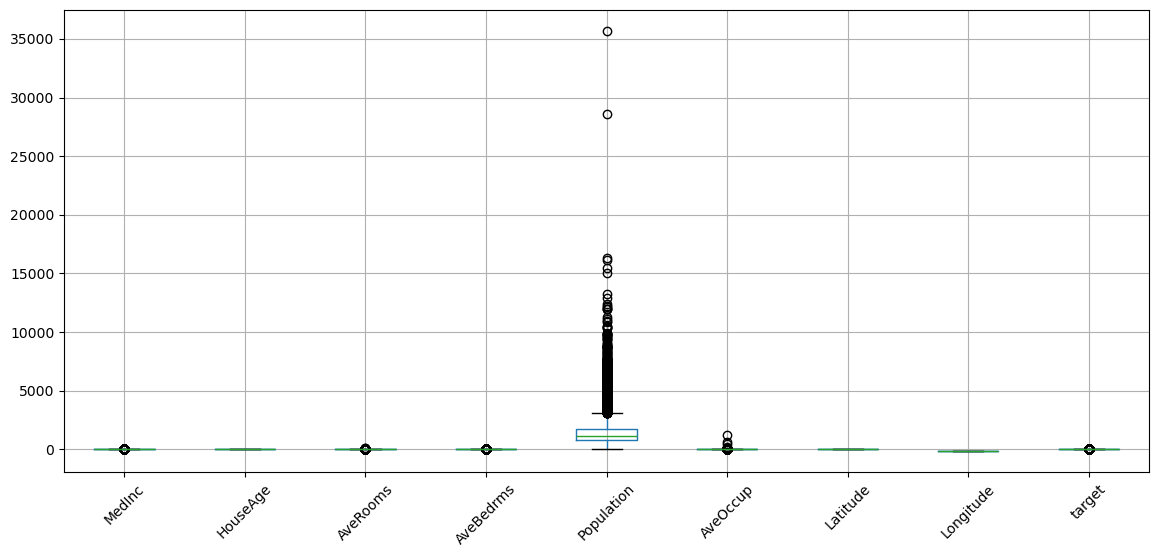

In [11]:
df.boxplot(figsize=(14,6))
plt.xticks(rotation=45)
plt.show()

In [12]:
def cap_outliers(df,column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR
    df[column] = df[column].clip(lower,upper)
    return df

df = cap_outliers(df,"Population")
df = cap_outliers(df, "AveOccup")

In [13]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1336.959012,2.899647,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,765.550830,0.691142,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,1.150961,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,3132.000000,4.561041,41.950000,-114.310000,5.000010


In [14]:
# ── 4. CORRELATION ANALYSIS ───────────────────────────────────

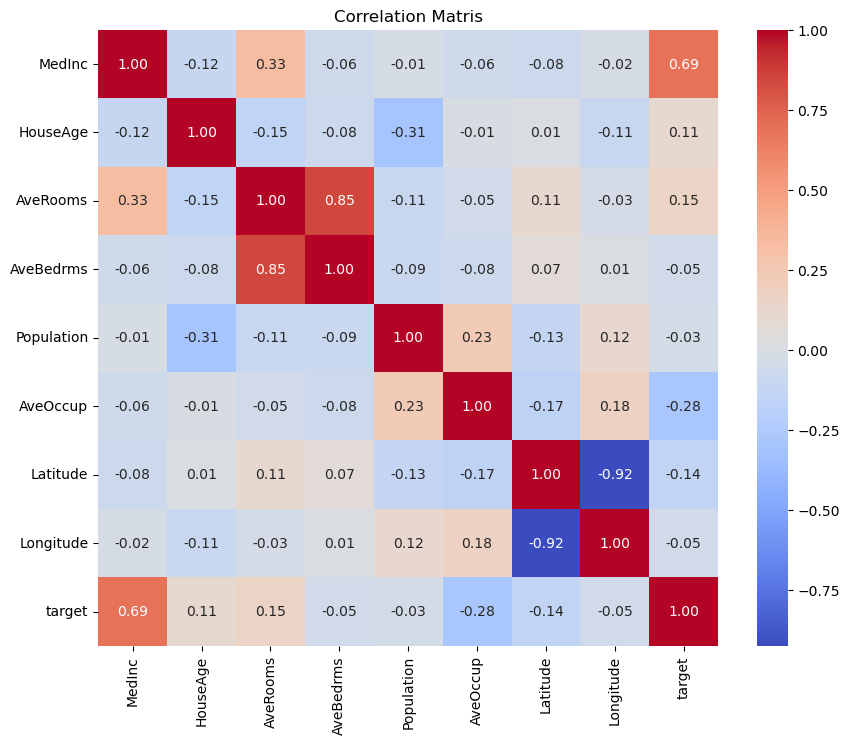

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matris')
plt.show()

In [16]:
# MedInc has the strongest correlation with target (0.69)
# AveRooms & AveBedrms are highly correlated with each other (0.82)
# → multicollinearity risk for Linear Regression

In [17]:
# ── 5. DROP MULTICOLLINEAR FEATURE ───────────────────────────
# AveBedrms dropped: corr with target only -0.05,
# and 0.82 correlated with AveRooms → redundant feature

In [18]:
df = df.drop(columns=['AveBedrms'])

In [19]:
# ── 6. TRAIN/TEST SPLIT ───────────────────────────────────────
from sklearn.model_selection import train_test_split

In [20]:
X = df.drop("target",axis=1)
y= df["target"]

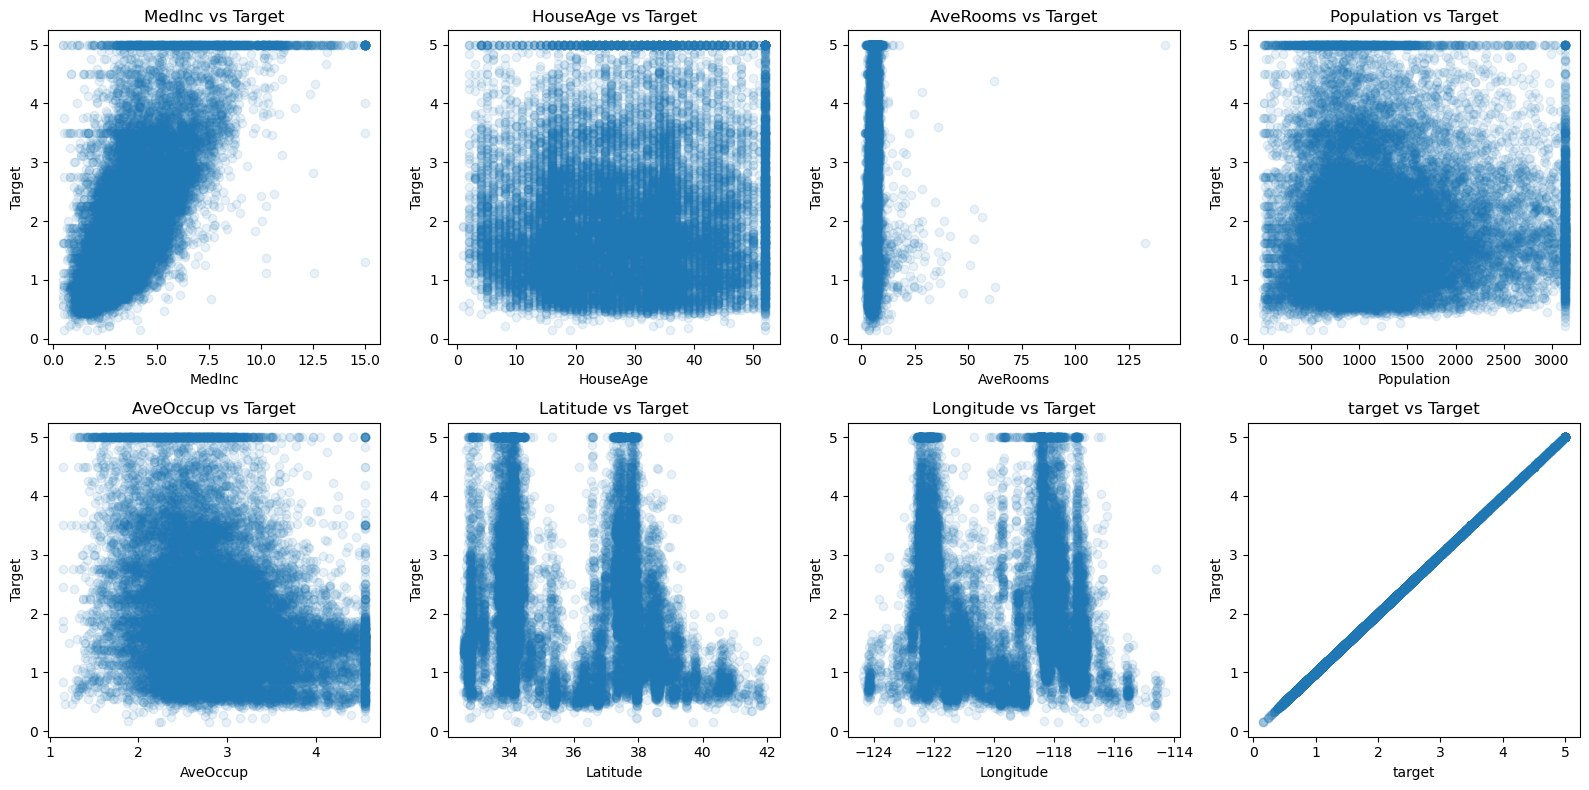

In [21]:
# Visualize relationship between each feature and target

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].scatter(df[col], y, alpha=0.1)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Target')
    axes[i].set_title(f'{col} vs Target')

plt.tight_layout()
plt.show()

In [22]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [23]:
X_train.shape

(16512, 7)

In [24]:
X_test.shape

(4128, 7)

In [25]:
# ── 7. SCALING ────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

In [26]:
scaler = StandardScaler()

In [27]:
X_train = scaler.fit_transform(X_train)# fit only on train!
X_test = scaler.transform(X_test) # transform only, no fit because test shouldn't know model

In [28]:
# ── 8. MODEL ──────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression

In [29]:
model = LinearRegression()

In [30]:
model.fit(X_train,y_train)

LinearRegression()

In [31]:
y_pred = model.predict(X_test)

In [32]:
y_pred

array([0.33771493, 1.88051224, 3.11047604, ..., 4.4025167 , 1.44498823,
       1.56969083])

In [33]:
# ── 9. METRICS ────────────────────────────────────────────────

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [35]:
mae = mean_absolute_error(y_test,y_pred)
mse= mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

In [36]:
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"r2: {r2:.4f}")

MAE: 0.5052
MSE: 0.4676
RMSE: 0.6838
r2: 0.6432


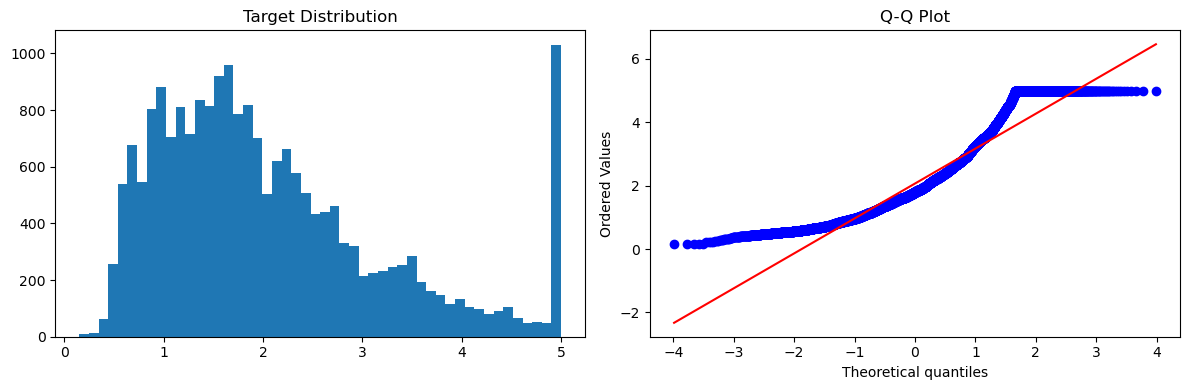

In [37]:
# Check target distribution
import scipy.stats as stats

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(y, bins=50)
plt.title('Target Distribution')

plt.subplot(1,2,2)

stats.probplot(y, plot=plt)
plt.title('Q-Q Plot')

plt.tight_layout()
plt.show()

In [38]:
from sklearn.preprocessing import PowerTransformer

In [39]:
pt = PowerTransformer(method="yeo-johnson")
y_transformed = pt.fit_transform(y.values.reshape(-1,1)).flatten()

In [40]:
plt.figure(figsize=(14,4))

<Figure size 1400x400 with 0 Axes>

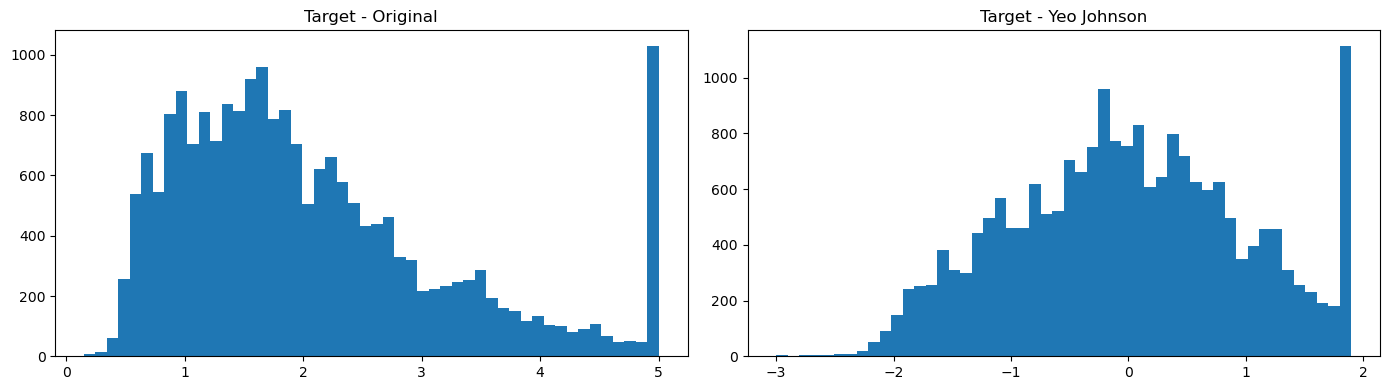

In [41]:
plt.subplot(1,2,1)
plt.hist(y,bins=50)
plt.title("Target - Original")

plt.subplot(1,2,2)
plt.hist(y_transformed,bins=50)
plt.title("Target - Yeo Johnson")

plt.tight_layout()
plt.show()

In [42]:
# ── 11. RETRAIN WITH TRANSFORMED TARGET ───────────────────────

In [43]:
X_train,X_test,y_train,y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)

In [44]:
scaler2 = StandardScaler()

In [45]:
X_train = scaler2.fit_transform(X_train)
X_test = scaler2.transform(X_test)

In [46]:
model2 = LinearRegression()
model2.fit(X_train,y_train)

LinearRegression()

In [47]:
y_pred2 = model2.predict(X_test)

In [48]:
# ── 12. METRICS ───────────────────────────────────────────────

In [49]:
mae  = mean_absolute_error(y_test, y_pred2)
mse  = mean_squared_error(y_test, y_pred2)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred2)

In [50]:
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

MAE:  0.4431
MSE:  0.3371
RMSE: 0.5806
R²:   0.6619


In [51]:
# Yeo-Johnson improved R² from 0.64 to 0.66

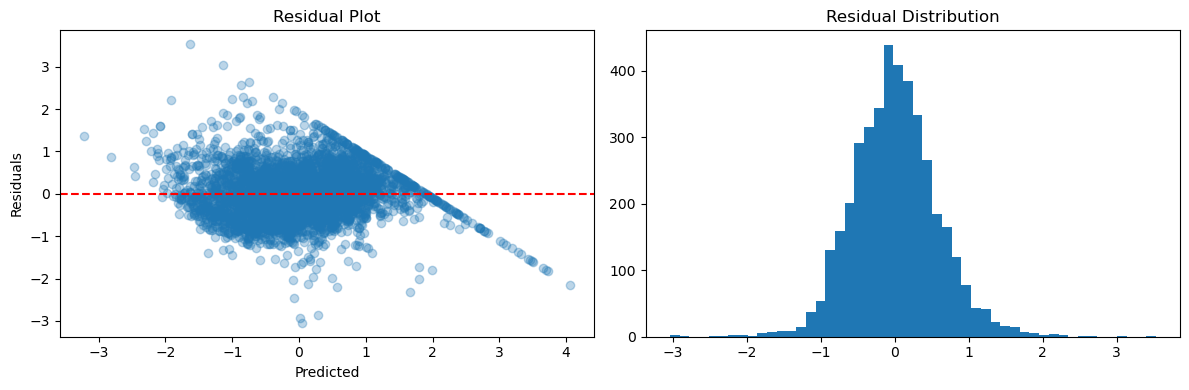

In [52]:
# ── 13. RESIDUAL PLOT ─────────────────────────────────────────
# Residuals = actual - predicted
# Good model: residuals randomly scattered around 0
# Bad model: pattern in residuals → model is missing something

residuals = y_test - y_pred2

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.scatter(y_pred2, residuals, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.subplot(1,2,2)
plt.hist(residuals, bins=50)
plt.title('Residual Distribution')

plt.tight_layout()
plt.show()

In [53]:
# ── 14. CROSS VALIDATION ──────────────────────────────────────
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    LinearRegression(), X_train, y_train,
    cv=5, scoring='r2'
)

print(f"CV Scores: {cv_scores}")
print(f"Mean R²:   {cv_scores.mean():.4f}")
print(f"Std:       {cv_scores.std():.4f}")

CV Scores: [0.68105511 0.66987355 0.67714782 0.68222088 0.6694171 ]
Mean R²:   0.6759
Std:       0.0054


In [54]:
train_r2 = r2_score(y_train, model2.predict(X_train))
test_r2  = r2_score(y_test, y_pred2)

print(f"Train R²: {train_r2:.4f}")
print(f"Test R²:  {test_r2:.4f}")

Train R²: 0.6764
Test R²:  0.6619


In [55]:
# Train R²: 0.6764 | Test R²: 0.6619 | Diff: 0.014
# No overfitting or underfitting detected
# Model is stable across folds (CV std: 0.0054)
# Low R² is expected — Linear Regression cannot capture
# non-linear relationships in this dataset
# Next step: try Polynomial Regression or tree-based models

In [56]:
# ── SUMMARY ───────────────────────────────────────────────────
# Dataset:   California Housing (20,640 samples, 8 features)
# Model:     Linear Regression
# R²:        0.66
# MAE:       0.50 ($50,000 average error)
# Key findings:
#   - MedInc is the strongest predictor (corr: 0.69)
#   - Multicollinearity detected between AveRooms & AveBedrms
#   - Non-linear relationships limit Linear Regression performance
#   - Stable model (CV std: 0.0054), no overfitting

In [57]:
# ── 15. POLYNOMIAL REGRESSION ────────────────────────────────
from sklearn.preprocessing import PolynomialFeatures


poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_train = poly.fit_transform(X_train)
X_poly_test  = poly.transform(X_test)

print(f"Original features:   {X_train.shape[1]}")
print(f"Polynomial features: {X_poly_train.shape[1]}")

Original features:   7
Polynomial features: 35


In [58]:
# ── 16. POLYNOMIAL MODEL ──────────────────────────────────────
# Features expanded from 7 to 35 (degree=2)
# Includes squared terms and interaction terms between features
# Risk: overfitting due to increased model complexity

model_poly = LinearRegression()
model_poly.fit(X_poly_train, y_train)
y_pred_poly = model_poly.predict(X_poly_test)

# Metrics
mae  = mean_absolute_error(y_test, y_pred_poly)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2   = r2_score(y_test, y_pred_poly)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

# Overfit check
train_r2 = r2_score(y_train, model_poly.predict(X_poly_train))
print(f"\nTrain R²: {train_r2:.4f}")
print(f"Test R²:  {r2:.4f}")
print(f"Diff:     {train_r2 - r2:.4f}")

MAE:  0.3968
RMSE: 0.5379
R²:   0.7098

Train R²: 0.7294
Test R²:  0.7098
Diff:     0.0196


In [59]:
# ── 17. POLYNOMIAL DEGREE=3 ───────────────────────────────────
# Testing higher degree to see if R² improves or overfitting occurs

poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_poly3_train = poly3.fit_transform(X_train)
X_poly3_test  = poly3.transform(X_test)

print(f"Polynomial features (degree=3): {X_poly3_train.shape[1]}")

model_poly3 = LinearRegression()
model_poly3.fit(X_poly3_train, y_train)
y_pred_poly3 = model_poly3.predict(X_poly3_test)

print(f"MAE:  {mean_absolute_error(y_test, y_pred_poly3):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_poly3)):.4f}")
print(f"R²:   {r2_score(y_test, y_pred_poly3):.4f}")

train_r2 = r2_score(y_train, model_poly3.predict(X_poly3_train))
test_r2  = r2_score(y_test, y_pred_poly3)
print(f"\nTrain R²: {train_r2:.4f}")
print(f"Test R²:  {test_r2:.4f}")
print(f"Diff:     {train_r2 - test_r2:.4f}")

Polynomial features (degree=3): 119
MAE:  0.3813
RMSE: 0.5477
R²:   0.6991

Train R²: 0.7564
Test R²:  0.6991
Diff:     0.0573


In [60]:
# degree=3: features increased 35 → 119
# Overfitting increased (diff: 0.014 → 0.057)
# R² dropped from 0.71 to 0.70 despite more complexity
# Conclusion: degree=2 is the optimal choice for this dataset
# Best model so far: Polynomial Regression (degree=2), R²=0.71

In [61]:
# ── 18. RIDGE REGRESSION ──────────────────────────────────────
# Linear Regression with L2 regularization
# Penalizes large coefficients → reduces overfitting
# Alpha: regularization strength (higher = more penalty)
# Unlike Lasso, Ridge shrinks coefficients but never makes them exactly 0

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Find best alpha via GridSearchCV
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100, 1000]}

ridge = Ridge()
grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

print(f"Best alpha: {grid_search.best_params_}")
print(f"Best CV R²: {grid_search.best_score_:.4f}")

# Train best model
best_ridge = grid_search.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)

print(f"\nMAE:  {mean_absolute_error(y_test, y_pred_ridge):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.4f}")
print(f"R²:   {r2_score(y_test, y_pred_ridge):.4f}")

train_r2 = r2_score(y_train, best_ridge.predict(X_train))
test_r2  = r2_score(y_test, y_pred_ridge)
print(f"\nTrain R²: {train_r2:.4f}")
print(f"Test R²:  {test_r2:.4f}")
print(f"Diff:     {train_r2 - test_r2:.4f}")

Best alpha: {'alpha': 0.01}
Best CV R²: 0.6759

MAE:  0.4431
RMSE: 0.5806
R²:   0.6619

Train R²: 0.6764
Test R²:  0.6619
Diff:     0.0145


In [62]:
# Ridge best alpha=0.01 (very low penalty)
# Performance identical to Linear Regression
# Reason: overfitting was never the problem here
# Ridge is effective when model overfits, not when relationships are non-linear

In [63]:
# ── 19. LASSO REGRESSION ──────────────────────────────────────
# Linear Regression with L1 regularization
# Key difference from Ridge: can shrink coefficients to exactly 0
# → automatic feature selection
# Higher alpha = more features eliminated

In [64]:
from sklearn.linear_model import Lasso

In [68]:
param_grid = {"alpha":[0.001,0.01,0.1,1,10,100]}
lasso = Lasso()
grid_search_lasso = GridSearchCV(lasso,param_grid, cv=5,scoring='r2')
grid_search_lasso.fit(X_train,y_train)

print(f"Best alpha : {grid_search_lasso.best_params_}")
print(f"Best CV R2 : {grid_search_lasso.best_score_:.4f}")

best_lasso = grid_search_lasso.best_estimator_
y_pred_lasso = best_lasso.predict(X_test)

print(f"\nMAE: {mean_absolute_error(y_test,y_pred_lasso):.4f}")
print(f"RMSE: {np.sqrt(mean_absolute_error(y_test,y_pred_lasso)):.4f}")
print(f"R2: {r2_score(y_test,y_pred_lasso):.4f}")

train_r2 = r2_score(y_train, best_lasso.predict(X_train))
test_r2 = r2_score(y_test, y_pred_lasso)

print(f"\nTrain R2 : {train_r2:.4f}")
print(f"Test R2: {test_r2:.4f}")
print(f"Diff: {(train_r2-test_r2):.4f}")

# Which features did Lasso eliminate?

feature_names = X.columns
coeffiecients = best_lasso.coef_

print("\nFeature Coefficients:")
for name , coef in zip(feature_names, coeffiecients):
    status ="ELIMINATED" if coef==0 else "kept"
    print(f"{name:15s}: {coef:.4f} -> {status}")


Best alpha : {'alpha': 0.001}
Best CV R2 : 0.6759

MAE: 0.4435
RMSE: 0.6659
R2: 0.6620

Train R2 : 0.6764
Test R2: 0.6620
Diff: 0.0144

Feature Coefficients:
MedInc         : 0.5479 -> kept
HouseAge       : 0.0823 -> kept
AveRooms       : 0.0507 -> kept
Population     : 0.0739 -> kept
AveOccup       : -0.2566 -> kept
Latitude       : -1.0678 -> kept
Longitude      : -0.9592 -> kept


In [69]:
# What happens with higher alpha?
for alpha in [0.001, 0.01, 0.1, 1]:
    lasso_test = Lasso(alpha=alpha)
    lasso_test.fit(X_train, y_train)
    n_eliminated = sum(lasso_test.coef_ == 0)
    r2 = r2_score(y_test, lasso_test.predict(X_test))
    print(f"Alpha: {alpha:.3f} | Eliminated: {n_eliminated} | R²: {r2:.4f}")

Alpha: 0.001 | Eliminated: 0 | R²: 0.6620
Alpha: 0.010 | Eliminated: 0 | R²: 0.6589
Alpha: 0.100 | Eliminated: 3 | R²: 0.4971
Alpha: 1.000 | Eliminated: 7 | R²: -0.0002


In [70]:
# Lasso best alpha=0.001 (very low, no features eliminated)
# Higher alpha eliminates features but R² drops significantly
# All 7 features contribute meaningfully to the model
# Lasso shines when there are many irrelevant features → not the case here

In [73]:
# ── 20. ELASTICNET REGRESSION ─────────────────────────────────
# Combines L1 (Lasso) and L2 (Ridge) regularization

In [74]:
from sklearn.linear_model import ElasticNet

In [80]:
param_grid = {
    "alpha" : [0.001,0.01,0.1,1],
    "l1_ratio" : [0.1,0.3,0.5,0.7,0.9]
}

elastic = ElasticNet()
grid_search_elastic = GridSearchCV(elastic,param_grid,cv=5,scoring='r2')
grid_search_elastic.fit(X_train,y_train)

print(f"Best params : {grid_search_elastic.best_params_}")
print(f"Best CV R2: {grid_search_elastic.best_score_}")

best_elastic = grid_search_elastic.best_estimator_
y_pred_elastic = best_elastic.predict(X_test)


print(f"\nMAE : {mean_absolute_error(y_test,y_pred_elastic):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test,y_pred_elastic)):.4f}")
print(f"R2 : {r2_score(y_test,y_pred_elastic):.4f}")

train_r2 = r2_score(y_train, best_elastic.predict(X_train))
test_r2  = r2_score(y_test, y_pred_elastic)
print(f"\nTrain R²: {train_r2:.4f}")
print(f"Test R²:  {test_r2:.4f}")
print(f"Diff:     {(train_r2 - test_r2):.4f}")

Best params : {'alpha': 0.001, 'l1_ratio': 0.1}
Best CV R2: 0.6758962233564976

MAE : 0.4434
RMSE : 0.5806
R2 : 0.6619

Train R²: 0.6764
Test R²:  0.6619
Diff:     0.0145


In [81]:
# ── FINAL SUMMARY ─────────────────────────────────────────────
# Ridge, Lasso, ElasticNet all converged to same performance
# Best alpha always near 0 → regularization not needed here
# Reason: dataset has no overfitting problem, only non-linearity
# Winner: Polynomial Regression (degree=2) with R²=0.71